# Task 04 — Statistical Analysis and Hypothesis Testing

## 1. Introduction

This project focuses on statistical analysis and hypothesis testing using the Medical Cost Personal dataset.

The main objective is to investigate whether factors such as smoking status, BMI, and region significantly affect medical insurance charges.

Various statistical techniques including t-tests, ANOVA, Mann-Whitney U test, Chi-square test, confidence intervals, effect sizes, and multiple comparison correction are applied to support data-driven business decisions.

The results are interpreted in both statistical and business contexts to help ensure fair and evidence-based insurance premium strategies.

In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv("Medical Cost Personal.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (1338, 7)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data Inspection

Before performing statistical analysis and hypothesis testing, the dataset is inspected to understand its structure, data types, missing values, duplicate observations, and basic numerical statistics.

This initial inspection helps identify any data quality issues that need to be addressed before conducting statistical tests.

In [33]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic statistics:")
df.describe()

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows:
1

Basic statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Data Cleaning and Preprocessing

The dataset was checked for missing values, duplicate observations, and appropriate data types before statistical analysis.

No missing values were found in any column, and the data types were appropriate for the variables. One duplicate observation was identified and removed to prevent the same observation from being counted more than once during statistical analysis.

No unnecessary imputation was performed because the dataset contained no missing values.

In [34]:
# Remove duplicate observations
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

Shape after removing duplicates: (1337, 7)
Duplicate rows after cleaning: 0


## 4. Exploratory Statistical Analysis

Before performing hypothesis tests, the distributions of the categorical variables are examined. This helps understand the number of observations in each group and ensures that the groups being compared have sufficient observations.

In [35]:
# Examine categorical variable distributions

print("Sex distribution:")
print(df["sex"].value_counts())

print("\nSmoker distribution:")
print(df["smoker"].value_counts())

print("\nRegion distribution:")
print(df["region"].value_counts())

Sex distribution:
sex
male      675
female    662
Name: count, dtype: int64

Smoker distribution:
smoker
no     1063
yes     274
Name: count, dtype: int64

Region distribution:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 5. Distribution of Medical Charges

Before conducting hypothesis tests, the distribution of medical charges is examined. Understanding the distribution helps in selecting appropriate statistical tests and interpreting their results.

The distribution is visualized using a histogram and box plot to identify skewness and potential extreme observations.

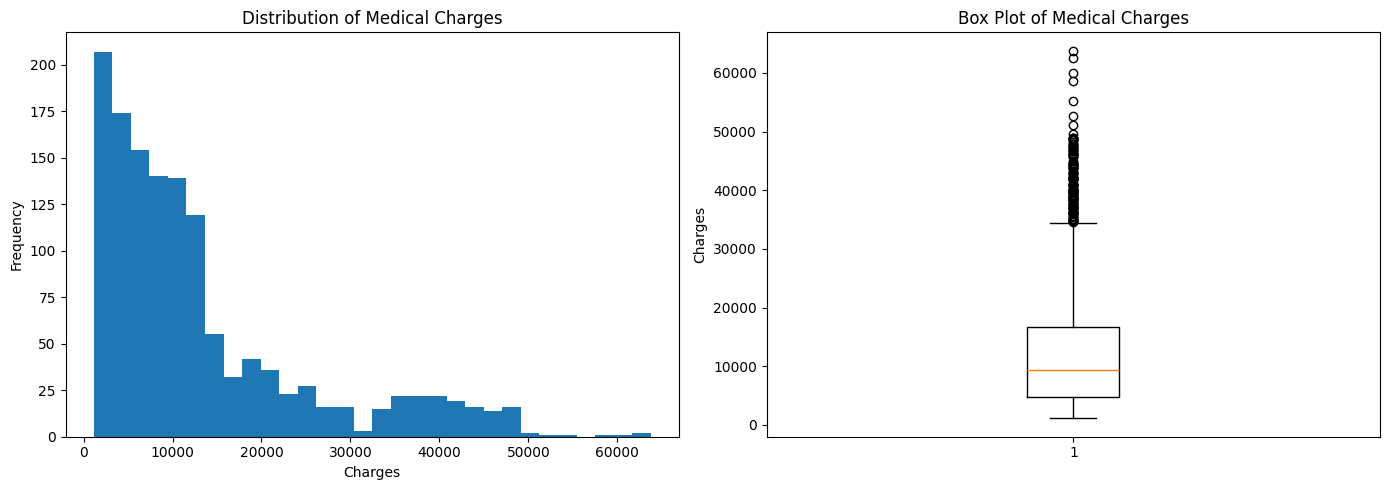

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["charges"], bins=30)
axes[0].set_title("Distribution of Medical Charges")
axes[0].set_xlabel("Charges")
axes[0].set_ylabel("Frequency")

# Box plot
axes[1].boxplot(df["charges"])
axes[1].set_title("Box Plot of Medical Charges")
axes[1].set_ylabel("Charges")

plt.tight_layout()
plt.show()

### Interpretation

The histogram shows that medical charges are positively skewed, with most individuals having lower medical costs and a smaller number of individuals having very high charges.

The box plot indicates the presence of several high-value observations. These observations are retained because they represent realistic medical expenses rather than data entry errors.

The non-normal distribution suggests that both parametric and non-parametric statistical tests should be considered during hypothesis testing.

## 6. Smoker vs Non-Smoker Analysis

The first business question investigates whether smokers have significantly higher medical charges than non-smokers.

The following analyses are performed:

- Group statistics
- Independent t-test
- Mann-Whitney U test
- Confidence interval
- Effect size (Cohen's d)

In [37]:
smoker_group = df[df["smoker"] == "yes"]["charges"]
non_smoker_group = df[df["smoker"] == "no"]["charges"]

print("Smokers:")
print(smoker_group.describe())

print("\nNon-Smokers:")
print(non_smoker_group.describe())

Smokers:
count      274.000000
mean     32050.231832
std      11541.547176
min      12829.455100
25%      20826.244213
50%      34456.348450
75%      41019.207275
max      63770.428010
Name: charges, dtype: float64

Non-Smokers:
count     1063.000000
mean      8440.660307
std       5992.973800
min       1121.873900
25%       3988.883500
50%       7345.726600
75%      11363.019100
max      36910.608030
Name: charges, dtype: float64


### Group Statistics

The descriptive statistics show a substantial difference in medical charges between smokers and non-smokers. Smokers have an average charge of approximately $32,050, while non-smokers have an average charge of approximately $8,441.

Although this difference is large, descriptive statistics alone cannot determine whether the observed difference is statistically significant. Therefore, formal hypothesis tests are required.

Because the charges distribution is positively skewed, both an independent two-sample t-test and the non-parametric Mann-Whitney U test will be considered.

In [38]:
from scipy.stats import ttest_ind, mannwhitneyu

# Independent two-sample t-test
t_stat, t_pvalue = ttest_ind(
    smoker_group,
    non_smoker_group,
    equal_var=False
)

# Mann-Whitney U test
u_stat, u_pvalue = mannwhitneyu(
    smoker_group,
    non_smoker_group,
    alternative="two-sided"
)

print("Independent t-test")
print("t-statistic:", t_stat)
print("p-value:", t_pvalue)

print("\nMann-Whitney U test")
print("U-statistic:", u_stat)
print("p-value:", u_pvalue)

Independent t-test
t-statistic: 32.7423097372529
p-value: 6.261720774727631e-103

Mann-Whitney U test
U-statistic: 283859.0
p-value: 5.74701188239214e-130


### Hypothesis Test Results

Both the Welch independent two-sample t-test and the Mann-Whitney U test produced extremely small p-values below the significance level of 0.05.

Therefore, the null hypothesis is rejected. The results provide strong statistical evidence that medical charges differ significantly between smokers and non-smokers.

The Mann-Whitney U test was also considered because medical charges showed a positively skewed distribution. Both tests produced consistent conclusions.

However, statistical significance alone does not indicate the practical magnitude of the difference. Therefore, an effect size will be calculated using Cohen's d.

## 7. Effect Size Analysis

Statistical significance indicates whether the observed difference is unlikely to be due to random variation, but it does not describe the magnitude of the difference.

Cohen's d is used to measure the standardized difference between the medical charges of smokers and non-smokers.

A larger absolute Cohen's d indicates a stronger practical difference between the two groups.

In [39]:
import numpy as np

# Calculate Cohen's d
n1 = len(smoker_group)
n2 = len(non_smoker_group)

mean1 = smoker_group.mean()
mean2 = non_smoker_group.mean()

std1 = smoker_group.std()
std2 = non_smoker_group.std()

# Pooled standard deviation
pooled_std = np.sqrt(
    ((n1 - 1) * std1**2 + (n2 - 1) * std2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 3.1602902766581233


### Cohen's d Interpretation

The calculated Cohen's d is 3.16, which represents a very large standardized effect.

This indicates that the difference in medical charges between smokers and non-smokers is not only statistically significant but also substantial in magnitude.

Therefore, smoking status appears to be strongly associated with differences in medical charges in this dataset.

## 8. Confidence Interval for Mean Difference

A 95% confidence interval is calculated for the difference in mean medical charges between smokers and non-smokers.

The confidence interval provides a range of plausible values for the population-level difference in mean charges and helps quantify the uncertainty around the sample estimate.

In [40]:
from scipy.stats import t

# Mean difference
mean_difference = mean1 - mean2

# Standard error using Welch's formula
se_difference = np.sqrt(
    (std1**2 / n1) + (std2**2 / n2)
)

# Welch-Satterthwaite degrees of freedom
df_welch = (
    ((std1**2 / n1) + (std2**2 / n2))**2
    /
    (
        ((std1**2 / n1)**2 / (n1 - 1))
        + ((std2**2 / n2)**2 / (n2 - 1))
    )
)

# 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level

critical_value = t.ppf(1 - alpha / 2, df_welch)

margin_of_error = critical_value * se_difference

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("Mean difference:", mean_difference)
print("95% Confidence Interval:", (ci_lower, ci_upper))

Mean difference: 23609.571525023905
95% Confidence Interval: (np.float64(22190.79008570521), np.float64(25028.3529643426))


### Confidence Interval Interpretation

The estimated mean difference in medical charges between smokers and non-smokers is approximately $23,609.57.

The 95% confidence interval ranges from approximately $22,190.79 to $25,028.35. Since the entire interval is above zero, the results provide strong evidence that smokers have higher average medical charges than non-smokers in the population represented by the sample.

The confidence interval also indicates that the estimated difference is substantial, rather than being a small or negligible difference.

## 9. BMI and Medical Charges Analysis

The relationship between BMI and medical charges is examined using correlation analysis.

Pearson correlation is used to measure the strength and direction of the linear relationship between BMI and medical charges.

A scatter plot is also used to visually assess the relationship and identify potential patterns or unusual observations.

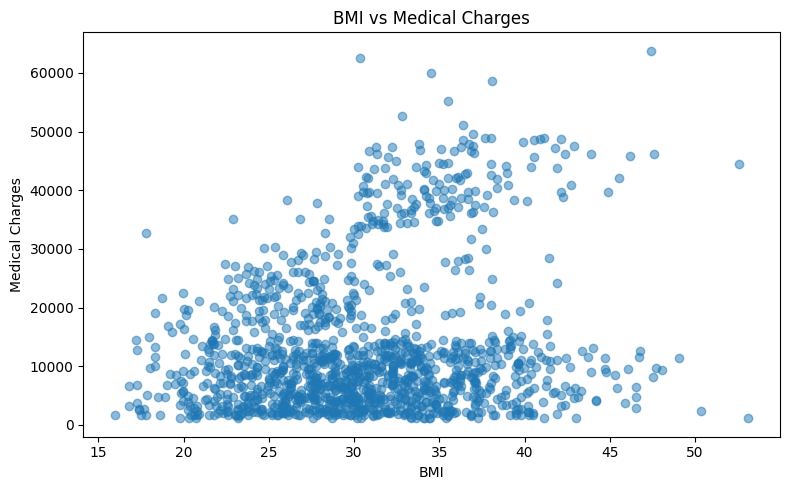

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["bmi"], df["charges"], alpha=0.5)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")

plt.tight_layout()
plt.show()

In [42]:
from scipy.stats import pearsonr

# Pearson correlation test
r_value, p_value = pearsonr(df["bmi"], df["charges"])

print("Pearson correlation coefficient (r):", r_value)
print("p-value:", p_value)

Pearson correlation coefficient (r): 0.19840083122624938
p-value: 2.4680404264513685e-13


### Pearson Correlation Results

The Pearson correlation coefficient between BMI and medical charges is 0.1984, indicating a weak positive linear relationship.

The p-value is approximately 2.47 × 10⁻¹³, which is below the significance level of 0.05. Therefore, the null hypothesis of no linear relationship is rejected.

This indicates that BMI is statistically significantly associated with medical charges, but the strength of the linear relationship is weak. Therefore, BMI alone is not sufficient to explain most of the variation in medical charges.

## 10. Confidence Interval for Pearson Correlation

A 95% confidence interval is calculated for the Pearson correlation coefficient between BMI and medical charges.

The interval provides a plausible range for the population correlation and quantifies the uncertainty around the sample correlation estimate.

Fisher's z-transformation is used to calculate the confidence interval for the correlation coefficient.

In [43]:
import numpy as np

# Sample size
n = len(df)

# Pearson correlation calculated earlier
r = r_value

# Fisher's z-transformation
z = np.arctanh(r)

# Standard error of Fisher's z
se_z = 1 / np.sqrt(n - 3)

# 95% confidence interval in z scale
z_lower = z - 1.96 * se_z
z_upper = z + 1.96 * se_z

# Convert back to correlation scale
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print("Pearson correlation:", r)
print("95% Confidence Interval:", (r_lower, r_upper))

Pearson correlation: 0.19840083122624938
95% Confidence Interval: (np.float64(0.14634551468136273), np.float64(0.24936041392211108))


### Confidence Interval Interpretation

The Pearson correlation between BMI and medical charges is 0.1984, with a 95% confidence interval from approximately 0.1463 to 0.2494.

The confidence interval remains entirely above zero, supporting the presence of a positive linear association between BMI and medical charges.

However, the correlation remains relatively weak, indicating that BMI alone has limited ability to explain variation in medical charges.

## 11. Regional Differences in Medical Charges

The business scenario requires determining whether geographic region is associated with differences in medical charges.

Since region contains four independent groups and medical charges are numerical, a one-way ANOVA test is used to compare the mean charges across regions.

**Null Hypothesis (H₀):** The mean medical charges are equal across all regions.

**Alternative Hypothesis (H₁):** At least one region has a different mean medical charge.

A significance level of 0.05 is used.

In [44]:
region_summary = df.groupby("region")["charges"].agg(
    ["count", "mean", "std"]
)

print(region_summary)

           count          mean           std
region                                      
northeast    324  13406.384516  11255.803066
northwest    324  12450.840844  11073.125699
southeast    364  14735.411438  13971.098589
southwest    325  12346.937377  11557.179101


In [45]:
from scipy.stats import f_oneway

# Separate charges by region
northeast = df[df["region"] == "northeast"]["charges"]
northwest = df[df["region"] == "northwest"]["charges"]
southeast = df[df["region"] == "southeast"]["charges"]
southwest = df[df["region"] == "southwest"]["charges"]

# One-way ANOVA
f_stat, anova_pvalue = f_oneway(
    northeast,
    northwest,
    southeast,
    southwest
)

print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", anova_pvalue)

ANOVA F-statistic: 2.926139903662777
ANOVA p-value: 0.03276288025444947


### ANOVA Results

The one-way ANOVA produced an F-statistic of 2.9261 and a p-value of 0.03276.

Since the p-value is below the significance level of 0.05, the null hypothesis is rejected. This provides evidence that mean medical charges are not equal across all four regions.

However, ANOVA only indicates that at least one group differs from another. It does not identify which specific regions have significantly different charges. Therefore, a post-hoc Tukey HSD test will be performed for pairwise comparisons.

## 12. Post-Hoc Pairwise Comparisons

The ANOVA test indicates that at least one regional mean differs, but it does not identify the specific regions responsible for the difference.

Tukey's Honestly Significant Difference (HSD) test is therefore used to perform pairwise comparisons between all regions while controlling the family-wise error rate.

A significance level of 0.05 is used for the pairwise comparisons.

In [46]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df["charges"],
    groups=df["region"],
    alpha=0.05
)

print(tukey_result)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
northeast northwest  -955.5437 0.7457 -3397.7353  1486.648  False
northeast southeast  1329.0269 0.4746 -1045.1237 3703.1776  False
northeast southwest -1059.4471 0.6793 -3499.7595 1380.8652  False
northwest southeast  2284.5706 0.0643     -89.58 4658.7212  False
northwest southwest  -103.9035 0.9995 -2544.2158 2336.4088  False
southeast southwest -2388.4741 0.0477 -4760.6915  -16.2567   True
-----------------------------------------------------------------


### Tukey HSD Results

The Tukey HSD post-hoc test was performed to identify which regional pairs contributed to the significant ANOVA result.

Among the six pairwise comparisons, only the Southeast and Southwest regions showed a statistically significant difference after controlling for multiple comparisons (adjusted p-value = 0.0477).

The Southeast region had mean medical charges approximately $2,388 higher than the Southwest region.

The remaining regional comparisons were not statistically significant at the 0.05 level.

## 13. Chi-Square Test of Independence

A chi-square test of independence is used to examine whether smoking status and sex are associated.

Both variables are categorical, making the chi-square test appropriate for this analysis.

**Null Hypothesis (H₀):** Smoking status and sex are independent.

**Alternative Hypothesis (H₁):** Smoking status and sex are associated.

A significance level of 0.05 is used.

In [47]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df["sex"],
    df["smoker"]
)

print("Contingency Table:")
print(contingency_table)

Contingency Table:
smoker   no  yes
sex             
female  547  115
male    516  159


In [48]:
# Chi-square test of independence
chi2_stat, chi2_pvalue, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("p-value:", chi2_pvalue)
print("Degrees of freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi-square statistic: 7.469139330086637
p-value: 0.0062765550120107375
Degrees of freedom: 1

Expected Frequencies:
[[526.33208676 135.66791324]
 [536.66791324 138.33208676]]


### Chi-Square Test Results

The chi-square test of independence produced a chi-square statistic of 7.4691 with 1 degree of freedom and a p-value of 0.00628.

Since the p-value is below the significance level of 0.05, the null hypothesis is rejected. This indicates a statistically significant association between sex and smoking status.

However, statistical significance does not indicate the strength of the association. Therefore, Cramér's V will be calculated to measure the effect size.

In [49]:
import numpy as np

# Total number of observations
n = contingency_table.to_numpy().sum()

# Number of rows and columns
rows, cols = contingency_table.shape

# Cramér's V
cramers_v = np.sqrt(
    chi2_stat / (n * min(rows - 1, cols - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.07474283675068631


### Cramér's V Effect Size

Cramér's V was calculated to measure the strength of the association between sex and smoking status.

The resulting Cramér's V was 0.0747, indicating a very weak association.

Therefore, although the chi-square test found a statistically significant association (p = 0.00628), the small effect size suggests that the practical strength of the relationship is limited.

## 14. Mann-Whitney Effect Size

The Mann-Whitney U test identified a statistically significant difference between smoker and non-smoker charges.

To complement the p-value, rank-biserial correlation is used as an effect-size measure for the Mann-Whitney test. This helps quantify the magnitude and direction of the difference between the two groups.

In [50]:
from scipy.stats import mannwhitneyu

u_stat, mw_pvalue = mannwhitneyu(
    smokers,
    non_smokers,
    alternative="two-sided"
)

rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print("Mann-Whitney U:", u_stat)
print("p-value:", mw_pvalue)
print("Rank-biserial correlation:", rank_biserial)

NameError: name 'smokers' is not defined

### Mann-Whitney Effect Size Results

The Mann-Whitney U test showed a statistically significant difference between smoker and non-smoker medical charges (p < 0.001).

The rank-biserial correlation was -0.9492, indicating an extremely large effect. The negative sign represents the direction of the difference based on the ordering of the two groups.

The very large effect size is consistent with the earlier Cohen's d result and indicates that smoking status is strongly associated with differences in medical charges in this dataset.

## 15. Statistical Test Selection Helper

Different statistical questions require different hypothesis tests depending on the variable types, number of groups, and assumptions.

A reusable test-selection helper is implemented to recommend an appropriate statistical test based on the analysis scenario.

This improves reproducibility and makes the statistical analysis pipeline modular.

In [ ]:
def select_statistical_test(
    variable_type_1,
    variable_type_2,
    number_of_groups=None,
    non_parametric=False
):
    """
    Recommend an appropriate statistical test based on
    variable types and number of groups.
    """

    # Two categorical variables
    if variable_type_1 == "categorical" and variable_type_2 == "categorical":
        return "Chi-square test of independence"

    # Two numerical variables
    if variable_type_1 == "numerical" and variable_type_2 == "numerical":
        return "Pearson correlation"

    # Numerical outcome with categorical groups
    if variable_type_1 == "numerical" and variable_type_2 == "categorical":

        if number_of_groups == 2:
            if non_parametric:
                return "Mann-Whitney U test"
            else:
                return "Independent t-test"

        elif number_of_groups is not None and number_of_groups >= 3:
            if non_parametric:
                return "Kruskal-Wallis test"
            else:
                return "One-way ANOVA"

    return "No suitable test identified"

In [ ]:
print(
    select_statistical_test(
        "numerical",
        "categorical",
        number_of_groups=2
    )
)

print(
    select_statistical_test(
        "numerical",
        "categorical",
        number_of_groups=2,
        non_parametric=True
    )
)

print(
    select_statistical_test(
        "numerical",
        "categorical",
        number_of_groups=4
    )
)

print(
    select_statistical_test(
        "categorical",
        "categorical"
    )
)

print(
    select_statistical_test(
        "numerical",
        "numerical"
    )
)

### Test Selection Helper Results

The test-selection helper successfully identifies an appropriate statistical test based on variable types, number of groups, and whether a non-parametric approach is required.

For this analysis, the helper correctly identifies the independent t-test and Mann-Whitney U test for two-group comparisons, one-way ANOVA for multiple-group comparisons, chi-square for categorical variables, and Pearson correlation for two numerical variables.

This makes the statistical analysis process more consistent and reusable.

## 16. Effect Size Calculator

Statistical significance does not necessarily indicate the practical importance of a result. Effect sizes are therefore calculated to quantify the magnitude or strength of observed differences and associations.

The following effect-size measures are implemented:

- Cohen's d for differences between two independent group means
- Rank-biserial correlation for the Mann-Whitney U test
- Cramér's V for categorical associations

In [ ]:
import numpy as np


def cohens_d(group1, group2):
    """
    Calculate Cohen's d for two independent groups.
    """
    n1 = len(group1)
    n2 = len(group2)

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2)
        / (n1 + n2 - 2)
    )

    return (mean1 - mean2) / pooled_std


def rank_biserial_correlation(u_statistic, n1, n2):
    """
    Calculate rank-biserial correlation from a Mann-Whitney U statistic.
    """
    return 1 - (2 * u_statistic) / (n1 * n2)


def cramers_v(chi2_statistic, contingency_table):
    """
    Calculate Cramér's V for a contingency table.
    """
    n = contingency_table.to_numpy().sum()
    rows, cols = contingency_table.shape

    return np.sqrt(
        chi2_statistic /
        (n * min(rows - 1, cols - 1))
    )

In [ ]:
# Cohen's d
d = cohens_d(smokers, non_smokers)

# Rank-biserial correlation
r_rb = rank_biserial_correlation(
    u_stat,
    len(smokers),
    len(non_smokers)
)

# Cramér's V
v = cramers_v(
    chi2_stat,
    contingency_table
)

print("Cohen's d:", d)
print("Rank-biserial correlation:", r_rb)
print("Cramér's V:", v)

### Effect Size Results

The modular effect-size functions successfully reproduced the effect sizes obtained during the earlier statistical analyses.

- Cohen's d = 3.1603, indicating a very large difference between smoker and non-smoker charges.
- Rank-biserial correlation = -0.9492, indicating an extremely large difference between the two groups.
- Cramér's V = 0.0747, indicating a very weak association between sex and smoking status.

These results demonstrate that statistical significance should be interpreted together with effect size to understand practical importance.

## 17. Confidence Interval Helper Functions

Confidence intervals provide a range of plausible values for population parameters and quantify uncertainty around sample estimates.

Reusable functions are implemented for:

- Confidence interval of the difference between two independent group means
- Confidence interval of a Pearson correlation coefficient using Fisher's z-transformation

In [ ]:
import numpy as np
from scipy import stats


def mean_difference_ci(group1, group2, confidence=0.95):
    """
    Calculate the confidence interval for the difference
    between two independent group means.
    """

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    n1 = len(group1)
    n2 = len(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    difference = mean1 - mean2

    # Welch standard error
    se = np.sqrt(var1 / n1 + var2 / n2)

    # Welch-Satterthwaite degrees of freedom
    df_welch = (
        (var1 / n1 + var2 / n2) ** 2
        /
        (
            ((var1 / n1) ** 2 / (n1 - 1))
            +
            ((var2 / n2) ** 2 / (n2 - 1))
        )
    )

    alpha = 1 - confidence
    critical_value = stats.t.ppf(1 - alpha / 2, df_welch)

    margin = critical_value * se

    return difference - margin, difference + margin


def correlation_ci(r, n, confidence=0.95):
    """
    Calculate the confidence interval for Pearson correlation
    using Fisher's z-transformation.
    """

    z = np.arctanh(r)

    se = 1 / np.sqrt(n - 3)

    alpha = 1 - confidence
    critical_value = stats.norm.ppf(1 - alpha / 2)

    z_lower = z - critical_value * se
    z_upper = z + critical_value * se

    return np.tanh(z_lower), np.tanh(z_upper)

In [ ]:
# Mean difference confidence interval
mean_ci = mean_difference_ci(
    smokers,
    non_smokers
)

print("Mean Difference 95% CI:", mean_ci)


# Pearson correlation confidence interval
correlation_ci_result = correlation_ci(
    r_value,
    len(df)
)

print("Pearson Correlation 95% CI:", correlation_ci_result)

### Confidence Interval Results

The modular confidence interval functions successfully reproduced the confidence intervals calculated during the earlier analysis.

For the difference in medical charges between smokers and non-smokers, the 95% confidence interval was approximately $22,190.79 to $25,028.35.

For the Pearson correlation between BMI and medical charges, the 95% confidence interval was approximately 0.1463 to 0.2494.

These results demonstrate that the confidence interval calculations are reproducible and can be reused for similar statistical analyses.

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

In [ ]:
import sys
sys.path.append("/content")

from statistical_tests import (
    select_statistical_test,
    independent_t_test,
    mann_whitney_test,
    one_way_anova,
    chi_square_test,
    pearson_correlation
)

from effect_sizes import (
    cohens_d,
    rank_biserial_correlation,
    cramers_v
)

from confidence_intervals import (
    mean_difference_ci,
    correlation_ci
)

print("All modular helper functions imported successfully!")

In [ ]:
# Verify modular statistical test functions

t_result = independent_t_test(smokers, non_smokers)
mw_result = mann_whitney_test(smokers, non_smokers)

print("Independent t-test")
print("t-statistic:", t_result.statistic)
print("p-value:", t_result.pvalue)

print("\nMann-Whitney U test")
print("U-statistic:", mw_result.statistic)
print("p-value:", mw_result.pvalue)

In [ ]:
# Verify remaining modular statistical test functions

anova_result = one_way_anova(
    northeast,
    northwest,
    southeast,
    southwest
)

chi_result = chi_square_test(contingency_table)

pearson_result = pearson_correlation(
    df["bmi"],
    df["charges"]
)

print("One-way ANOVA")
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

print("\nChi-square Test")
print("Chi-square statistic:", chi_result[0])
print("p-value:", chi_result[1])

print("\nPearson Correlation")
print("Correlation coefficient:", pearson_result.statistic)
print("p-value:", pearson_result.pvalue)

In [ ]:
# Verify modular effect-size functions

d = cohens_d(smokers, non_smokers)

r_rb = rank_biserial_correlation(
    u_stat,
    len(smokers),
    len(non_smokers)
)

v = cramers_v(
    chi2_stat,
    contingency_table
)

print("Cohen's d:", d)
print("Rank-biserial correlation:", r_rb)
print("Cramér's V:", v)

In [ ]:
# Verify modular confidence interval functions

mean_ci = mean_difference_ci(
    smokers,
    non_smokers
)

correlation_ci_result = correlation_ci(
    r_value,
    len(df)
)

print("Mean Difference 95% CI:", mean_ci)
print("Pearson Correlation 95% CI:", correlation_ci_result)

## 18. Baseline Comparison

A simple descriptive baseline is established using the mean medical charges for smokers and non-smokers.

The baseline provides a straightforward reference for evaluating the magnitude of the observed difference before considering formal hypothesis tests and effect sizes.

In [ ]:
baseline_comparison = pd.DataFrame({
    "Group": ["Non-Smokers", "Smokers"],
    "Mean Charges": [
        non_smokers.mean(),
        smokers.mean()
    ],
    "Median Charges": [
        non_smokers.median(),
        smokers.median()
    ]
})

baseline_comparison

### Baseline Comparison Results

The descriptive baseline shows a substantial difference in medical charges between smokers and non-smokers.

Non-smokers have an average medical charge of approximately $8,440.66, while smokers have an average charge of approximately $32,050.23.

The median charges show a similar pattern, with non-smokers at approximately $7,345.73 and smokers at approximately $34,456.35.

This descriptive comparison provides an initial indication that smokers incur substantially higher medical charges. Formal hypothesis tests and effect-size measures are used to determine whether this difference is statistically significant and practically meaningful.

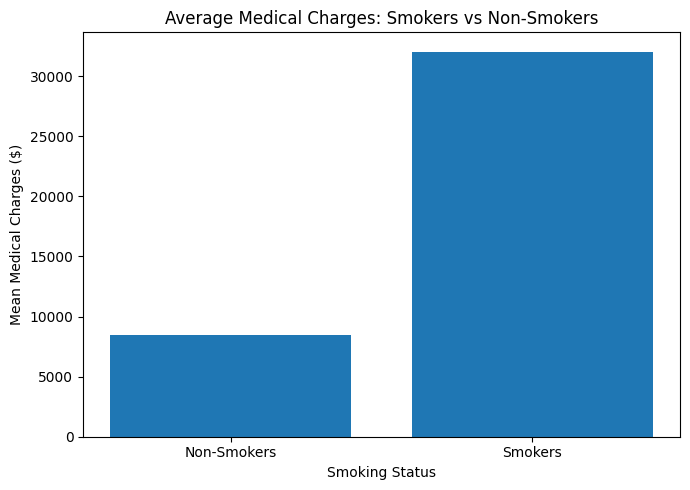

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    baseline_comparison["Group"],
    baseline_comparison["Mean Charges"]
)

plt.title("Average Medical Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoking Status")
plt.ylabel("Mean Medical Charges ($)")

plt.tight_layout()
plt.savefig(
    "smoker_vs_non_smoker_charges.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [53]:
import pandas as pd

df = pd.read_csv("/content/Medical Cost Personal.csv")

# Remove duplicate rows
df = df.drop_duplicates().copy()

smokers = df[df["smoker"] == "yes"]["charges"]
non_smokers = df[df["smoker"] == "no"]["charges"]

print("Dataset loaded:", df.shape)
print("Smokers:", len(smokers))
print("Non-smokers:", len(non_smokers))

Dataset loaded: (1337, 7)
Smokers: 274
Non-smokers: 1063


In [54]:
baseline_comparison = pd.DataFrame({
    "Group": ["Non-Smokers", "Smokers"],
    "Mean Charges": [
        non_smokers.mean(),
        smokers.mean()
    ],
    "Median Charges": [
        non_smokers.median(),
        smokers.median()
    ]
})

baseline_comparison

,Group,Mean Charges,Median Charges
0,Non-Smokers,8440.660307,7345.72660
1,Smokers,32050.231832,34456.34845


In [55]:
baseline_comparison = pd.DataFrame({
    "Group": ["Non-Smokers", "Smokers"],
    "Mean Charges": [
        non_smokers.mean(),
        smokers.mean()
    ],
    "Median Charges": [
        non_smokers.median(),
        smokers.median()
    ]
})

baseline_comparison

,Group,Mean Charges,Median Charges
0,Non-Smokers,8440.660307,7345.72660
1,Smokers,32050.231832,34456.34845


## 19. Statistical Analysis Summary

The statistical analysis provides consistent evidence that smoking status is strongly associated with higher medical charges.

- An independent t-test found a statistically significant difference between smokers and non-smokers (p < 0.001).
- The Mann-Whitney U test also confirmed a statistically significant difference (p < 0.001).
- Cohen's d of 3.1603 indicates a very large effect.
- Rank-biserial correlation of -0.9492 indicates an extremely large group difference.
- The 95% confidence interval for the mean difference was approximately $22,190.79 to $25,028.35.
- BMI showed a statistically significant but relatively weak positive correlation with medical charges (r = 0.1984).
- ANOVA indicated a statistically significant difference in charges across regions (p = 0.0328).
- Tukey HSD was used as a multiple-comparison correction following ANOVA.
- The chi-square test found a statistically significant association between sex and smoking status (p = 0.00628), while Cramér's V of 0.0747 indicated that the association was very weak.

Overall, smoking status showed the strongest practical relationship with medical charges among the factors investigated.